--2026-01-28 15:10:12--  https://snap.stanford.edu/data/facebook_combined.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 218576 (213K) [application/x-gzip]
Saving to: ‘facebook_combined.txt.gz’

facebook_combined.t 100%[===================>] 213.45K  --.-KB/s    in 0.1s    

2026-01-28 15:10:12 (1.86 MB/s) - ‘facebook_combined.txt.gz’ saved [218576/218576]

gzip: facebook_combined.txt already exists; do you wish to overwrite (y or n)? y
Total edges (M): 88234
Total nodes (N): 4039
Edges used: 882, Giant Component Ratio: 0.039
Edges used: 3894, Giant Component Ratio: 0.471
Edges used: 6906, Giant Component Ratio: 0.623
Edges used: 9918, Giant Component Ratio: 0.750
Edges used: 12930, Giant Component Ratio: 0.841
Edges used: 15942, Giant Component Ratio: 0.871
Edges used: 18955, Giant Component Ratio: 0.892
Edges used: 21967, G

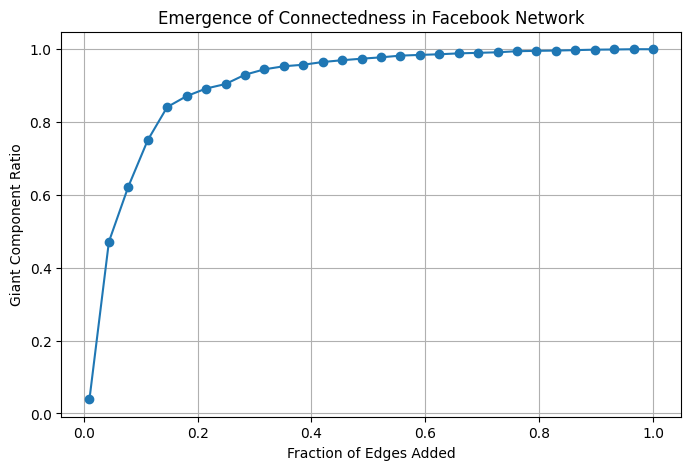

In [4]:
# ============================================================
# PROGRAMMING ILLUSTRATION:
# Emergence of Connectedness in Facebook Social Network
# ============================================================
# Definition:
# Emergence of Connectedness refers to the phenomenon where
# a large "Giant Connected Component" suddenly appears in a
# network as more edges are added.
#
# Graph G = (V, E)
# V = set of nodes (users)
# E = set of edges (friendships)
#
# ------------------------------------------------------------


# ============================================================
# Step 0: Download Dataset (Google Colab)
# ============================================================
# Downloads and extracts Facebook combined network
# Source: SNAP Stanford

!wget https://snap.stanford.edu/data/facebook_combined.txt.gz && gunzip facebook_combined.txt.gz


# ============================================================
# Step 1: Import Required Libraries
# ============================================================
# networkx   → network construction and analysis
# numpy      → numerical operations
# matplotlib → plotting graphs
# random     → shuffling edges

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random


# ============================================================
# Step 2: Load Edge List
# ============================================================
# Each line in file:
# u v  → edge between node u and node v

file_path = "facebook_combined.txt"

edges = []
with open(file_path, "r") as f:
    for line in f:
        u, v = map(int, line.split())
        edges.append((u, v))

print("Total edges (M):", len(edges))


# ============================================================
# Step 3: Extract Unique Nodes
# ============================================================
# V = set of all users appearing in edge list

nodes = set()
for u, v in edges:
    nodes.add(u)
    nodes.add(v)

N = len(nodes)
print("Total nodes (N):", N)


# ============================================================
# Step 4: Shuffle Edges Randomly
# ============================================================
# Purpose:
# Simulates random growth of the network

random.shuffle(edges)


# ============================================================
# Step 5: Prepare Fractions of Edges
# ============================================================
# We add edges gradually from 1% to 100%
#
# Edge Fraction = M_used / M_total

fractions = np.linspace(0.01, 1.0, 30)
giant_component_ratios = []


# ============================================================
# Step 6: Incremental Network Construction
# ============================================================
# For each fraction:
#   1. Create graph
#   2. Add subset of edges
#   3. Find connected components
#   4. Compute Giant Component Ratio
#
# ------------------------------------------------------------
# Giant Component Ratio (GCR) Formula:
#
#           |C_max|
#   GCR =  ---------
#             N
#
# |C_max| = size of largest connected component
# N       = total number of nodes
# ------------------------------------------------------------

for frac in fractions:

    # Create empty undirected graph
    G = nx.Graph()

    # Add all nodes
    G.add_nodes_from(nodes)

    # Number of edges to use
    M_used = int(frac * len(edges))

    # Add first M_used edges
    G.add_edges_from(edges[:M_used])

    # Find all connected components
    components = list(nx.connected_components(G))

    # Largest connected component
    largest_cc = max(components, key=len)

    # Giant Component Ratio
    gcr = len(largest_cc) / N
    giant_component_ratios.append(gcr)

    print(f"Edges used: {M_used}, Giant Component Ratio: {gcr:.3f}")


# ============================================================
# Step 7: Visualization
# ============================================================
# X-axis: Fraction of edges added
# Y-axis: Giant Component Ratio
#
# A sharp rise indicates:
# Phase Transition → Emergence of Connectedness

plt.figure(figsize=(8,5))
plt.plot(fractions, giant_component_ratios, marker='o')
plt.xlabel("Fraction of Edges Added")
plt.ylabel("Giant Component Ratio")
plt.title("Emergence of Connectedness in Facebook Network")
plt.grid(True)
plt.show()


# ============================================================
# End of Program
# ============================================================
